## This script will compare the means and extremes for a single year between the compressed and uncompressed data. 
To generate the extracted variables I made the script merge_cdo

In [2]:
import os
import xarray as xr
import pandas as pd
from dask.diagnostics import ProgressBar

# Set your paths
uncompressed_dir = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/DATA/CanESM2-WRF-original/merged/'
compressed_dir = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/DATA/CanESM2-WRF-extracted_cmpr/merged/'

In [4]:
import pandas as pd

df = pd.read_csv('compression_comparison_summary_1986.csv')
display(df)

,file,variable,mean_uncompressed,mean_compressed,diff_mean,perc1_uncompressed,perc1_compressed,diff_perc1,perc5_uncompressed,perc5_compressed,...,diff_perc0,perc75_uncompressed,perc75_compressed,diff_perc75,perc95_uncompressed,perc95_compressed,diff_perc95,perc99_uncompressed,perc99_compressed,diff_perc99
0,1986_pr_d03.nc,pr,629.535339,629.535342,2.334454e-06,20.816692,20.816406,-2.856636e-04,66.246554,66.246803,...,4.023314e-07,824.553015,824.552877,-1.382604e-04,1719.005681,1719.005735,0.000055,2888.042313,2888.042177,-0.000136
1,1986_t_d03.nc,T2,279.577045,279.577060,1.532355e-05,252.496628,252.500000,3.372192e-03,262.803925,262.804688,...,2.334595e-03,285.359131,285.359375,2.441406e-04,291.727051,291.726562,-0.000488,299.391174,299.390625,-0.000549
2,1986_wind_d03.nc,wspd,5.136957,5.136957,2.207792e-07,0.358300,0.358300,3.010035e-08,0.882641,0.882641,...,3.929017e-10,7.093593,7.093594,4.768372e-07,12.121865,12.121865,0.000000,16.214508,16.214508,0.000000


In [5]:
import numpy as np

# Example percentiles used above
#percentiles = [1, 5, 50, 95, 99]

# Mean
df['relerr_mean'] = np.where(
    np.abs(df['mean_uncompressed']) > 1e-12, 
    (df['mean_compressed'] - df['mean_uncompressed']) / np.abs(df['mean_uncompressed']), 
    np.nan
)
df['relerr_mean_pct'] = 100 * df['relerr_mean']

# Percentiles
for p in percentiles:
    uncomp_col = f'perc{p}_uncompressed'
    comp_col = f'perc{p}_compressed'
    relerr_col = f'relerr_perc{p}'
    relerr_pct_col = f'relerr_perc{p}_pct'
    df[relerr_col] = np.where(
        np.abs(df[uncomp_col]) > 1e-12, 
        (df[comp_col] - df[uncomp_col]) / np.abs(df[uncomp_col]), 
        np.nan
    )
    df[relerr_pct_col] = 100 * df[relerr_col]

display(df)

,file,variable,mean_uncompressed,mean_compressed,diff_mean,perc1_uncompressed,perc1_compressed,diff_perc1,perc5_uncompressed,perc5_compressed,...,relerr_perc25,relerr_perc25_pct,relerr_perc0,relerr_perc0_pct,relerr_perc75,relerr_perc75_pct,relerr_perc95,relerr_perc95_pct,relerr_perc99,relerr_perc99_pct
0,1986_pr_d03.nc,pr,629.535339,629.535342,2.334454e-06,20.816692,20.816406,-2.856636e-04,66.246554,66.246803,...,-7.758668e-07,-0.000078,0.000005,0.000481,-1.676792e-07,-0.000017,3.184452e-08,0.000003,-4.712826e-08,-0.000005
1,1986_t_d03.nc,T2,279.577045,279.577060,1.532355e-05,252.496628,252.500000,3.372192e-03,262.803925,262.804688,...,1.097865e-05,0.001098,0.000010,0.001018,8.555557e-07,0.000086,-1.673761e-06,-0.000167,-1.834778e-06,-0.000183
2,1986_wind_d03.nc,wspd,5.136957,5.136957,2.207792e-07,0.358300,0.358300,3.010035e-08,0.882641,0.882641,...,9.560995e-08,0.000010,0.000003,0.000254,6.722082e-08,0.000007,0.000000e+00,0.000000,0.000000e+00,0.000000


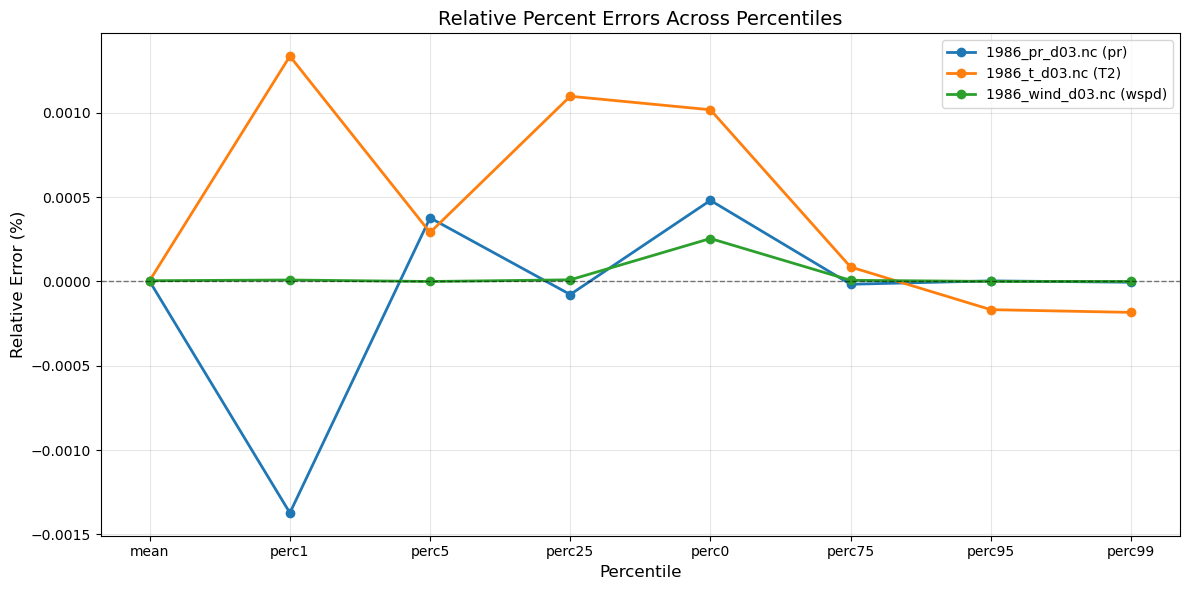

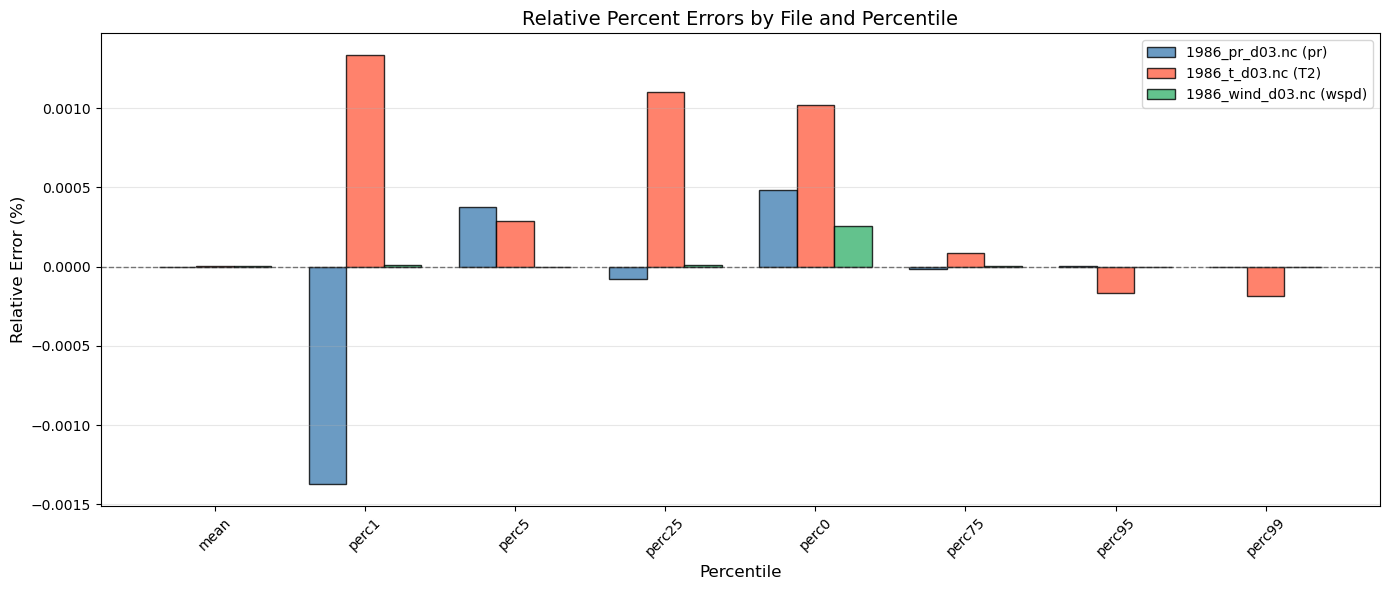

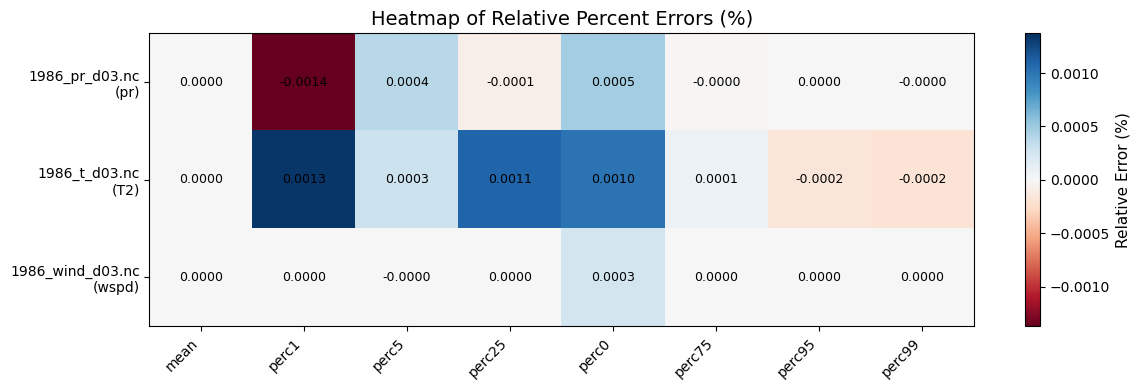


── Percent Error Summary ──
            file variable  relerr_mean_pct  relerr_perc1_pct  relerr_perc5_pct  relerr_perc25_pct  relerr_perc0_pct  relerr_perc75_pct  relerr_perc95_pct  relerr_perc99_pct
  1986_pr_d03.nc       pr     3.708218e-07         -0.001372      3.768559e-04          -0.000078          0.000481          -0.000017           0.000003          -0.000005
   1986_t_d03.nc       T2     5.480975e-06          0.001336      2.903075e-04           0.001098          0.001018           0.000086          -0.000167          -0.000183
1986_wind_d03.nc     wspd     4.297860e-06          0.000008     -3.376496e-07           0.000010          0.000254           0.000007           0.000000           0.000000

Max absolute % error: 0.001372%
Mean absolute % error: 0.000283%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming your dataframe is called 'df'
# Extract percent error columns (columns ending with '_pct')
pct_columns = [col for col in df.columns if col.endswith('_pct')]

# Extract percentile labels for x-axis
percentile_labels = [col.replace('relerr_', '').replace('_pct', '') 
                     for col in pct_columns]

# ── 1. Line Plot: Percent Errors Across Percentiles ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for _, row in df.iterrows():
    label = f"{row['file']} ({row['variable']})"
    values = row[pct_columns].values
    ax.plot(percentile_labels, values, marker='o', label=label, linewidth=2)

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Relative Percent Errors Across Percentiles', fontsize=14)
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('percent_errors_line.png', dpi=150)
plt.show()

# ── 2. Grouped Bar Chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

n_files = len(df)
n_percentiles = len(pct_columns)
x = np.arange(n_percentiles)
width = 0.25  # bar width

colors = ['steelblue', 'tomato', 'mediumseagreen']

for i, (_, row) in enumerate(df.iterrows()):
    label = f"{row['file']} ({row['variable']})"
    values = row[pct_columns].values
    offset = (i - n_files / 2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=label, 
                  color=colors[i % len(colors)], alpha=0.8, edgecolor='black')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Relative Percent Errors by File and Percentile', fontsize=14)
ax.set_xlabel('Percentile', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(percentile_labels, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('percent_errors_bar.png', dpi=150)
plt.show()

# ── 3. Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Build matrix: rows = files, cols = percentiles
labels = [f"{row['file']}\n({row['variable']})" for _, row in df.iterrows()]
matrix = df[pct_columns].values

im = ax.imshow(matrix, cmap='RdBu', aspect='auto',
               norm=plt.Normalize(vmin=-np.max(np.abs(matrix)), 
                                   vmax=np.max(np.abs(matrix))))

# Annotate cells
for i in range(len(labels)):
    for j in range(n_percentiles):
        ax.text(j, i, f"{matrix[i, j]:.4f}",
                ha='center', va='center', fontsize=9,
                color='black' if abs(matrix[i, j]) < 0.5 else 'white')

ax.set_xticks(np.arange(n_percentiles))
ax.set_xticklabels(percentile_labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Heatmap of Relative Percent Errors (%)', fontsize=14)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Relative Error (%)', fontsize=11)
plt.tight_layout()
plt.savefig('percent_errors_heatmap.png', dpi=150)
plt.show()

# ── 4. Summary Statistics Print ───────────────────────────────────────────────
print("\n── Percent Error Summary ──")
print(df[['file', 'variable'] + pct_columns].to_string(index=False))
print(f"\nMax absolute % error: {df[pct_columns].abs().values.max():.6f}%")
print(f"Mean absolute % error: {df[pct_columns].abs().values.mean():.6f}%")